In [1]:
import numpy as np
import matplotlib.pyplot as plt 

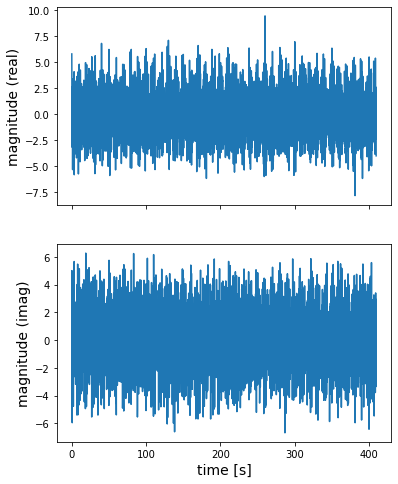

In [21]:
delta_f_ratio, time_change = 1e-5, 1200
amp_init, amp_last, f_init, f_last = 1.1, 1.1, 1.4, 3.3

sampling_rate = 10

def schottky_decay_signal(amp_init, amp_last, f_init, f_last, time_change, delta_f_ratio, sampling_rate, detector_pos_0=0, detector_pos_1=np.pi, detector_pos_2=np.pi/2, phase_noise_detectorDiff=True, phase_noise_on=False, amplitude_noise_on=False, noise_scale=.01):
    num = 100000
    t_range = np.arange(num) / sampling_rate
    change_before = np.where(t_range<time_change, 1, 0)
    change_after = np.where(t_range>=time_change, 1, 0)
    if phase_noise_on:
        if phase_noise_detectorDiff:
            sig_0 = (change_before * amp_init*np.exp(1j*(2*np.pi*(f_init+np.random.normal(scale=delta_f_ratio*f_init))*t_range + detector_pos_0)) 
                  + change_after * amp_last*np.exp(1j*(2*np.pi*(f_last+np.random.normal(scale=delta_f_ratio*f_last))*(t_range-time_change) + detector_pos_0 + 2*np.pi*f_init*time_change)))
            sig_1 = (change_before * amp_init*np.exp(1j*(2*np.pi*(f_init+np.random.normal(scale=delta_f_ratio*f_init))*t_range + detector_pos_1)) 
                  + change_after * amp_last*np.exp(1j*(2*np.pi*(f_last+np.random.normal(scale=delta_f_ratio*f_last))*(t_range-time_change) + detector_pos_1 + 2*np.pi*f_init*time_change)))
            sig_2 = (change_before * amp_init*np.exp(1j*(2*np.pi*(f_init+np.random.normal(scale=delta_f_ratio*f_init))*t_range + detector_pos_2)) 
                  + change_after * amp_last*np.exp(1j*(2*np.pi*(f_last+np.random.normal(scale=delta_f_ratio*f_last))*(t_range-time_change) + detector_pos_2 + 2*np.pi*f_init*time_change)))
        else:
            phase_random_0 = np.random.normal(scale=delta_f_ratio*f_init, size=num)
            phase_random_1 = np.random.normal(scale=delta_f_ratio*f_last, size=num)
            sig_0 = (change_before * amp_init*np.exp(1j*(2*np.pi*(f_init+phase_random_0)*t_range + detector_pos_0)) 
                  + change_after * amp_last*np.exp(1j*(2*np.pi*(f_last+phase_random_1)*(t_range-time_change) + detector_pos_0 + 2*np.pi*f_init*time_change)))
            sig_1 = (change_before * amp_init*np.exp(1j*(2*np.pi*(f_init+phase_random_0)*t_range + detector_pos_1)) 
                  + change_after * amp_last*np.exp(1j*(2*np.pi*(f_last+phase_random_1)*(t_range-time_change) + detector_pos_1 + 2*np.pi*f_init*time_change)))
            sig_2 = (change_before * amp_init*np.exp(1j*(2*np.pi*(f_init+phase_random_0)*t_range + detector_pos_2)) 
                  + change_after * amp_last*np.exp(1j*(2*np.pi*(f_last+phase_random_1)*(t_range-time_change) + detector_pos_2 + 2*np.pi*f_init*time_change)))
    else:
        sig_0 = (change_before * amp_init*np.exp(1j*(2*np.pi*f_init*t_range + detector_pos_0)) 
               + change_after * amp_last*np.exp(1j*(2*np.pi*f_last*(t_range-time_change) + detector_pos_0 + 2*np.pi*f_init*time_change)))
        sig_1 = (change_before * amp_init*np.exp(1j*(2*np.pi*f_init*t_range + detector_pos_1)) 
               + change_after * amp_last*np.exp(1j*(2*np.pi*f_last*(t_range-time_change) + detector_pos_1 + 2*np.pi*f_init*time_change)))
        sig_2 = (change_before * amp_init*np.exp(1j*(2*np.pi*f_init*t_range + detector_pos_2)) 
               + change_after * amp_last*np.exp(1j*(2*np.pi*f_last*(t_range-time_change) + detector_pos_2 + 2*np.pi*f_init*time_change)))
    if amplitude_noise_on:
        sig_0 +=  np.random.normal(size=num, scale=noise_scale) + 1j*np.random.normal(size=num, scale=noise_scale)
        sig_1 +=  np.random.normal(size=num, scale=noise_scale) + 1j*np.random.normal(size=num, scale=noise_scale)
        sig_2 +=  np.random.normal(size=num, scale=noise_scale) + 1j*np.random.normal(size=num, scale=noise_scale)
    for f_stable, amp_stable in zip([1.3, 0.7, 3.2], [2.1, 1.0, 1.3]):
        sig_0 += amp_stable*np.exp(1j*(2*np.pi*f_stable*t_range+detector_pos_0))
        sig_1 += amp_stable*np.exp(1j*(2*np.pi*f_stable*t_range+detector_pos_1))
        sig_2 += amp_stable*np.exp(1j*(2*np.pi*f_stable*t_range+detector_pos_2))
    return t_range, sig_0, sig_1, sig_2

t_range, sig_0, sig_1, sig_2 = schottky_decay_signal(amp_init=amp_init, amp_last=amp_last, f_init=f_init, f_last=f_last, time_change=time_change, delta_f_ratio=delta_f_ratio, sampling_rate=sampling_rate, phase_noise_detectorDiff=False, phase_noise_on=True, amplitude_noise_on=True, noise_scale=1.)

%matplotlib inline
fig, ax = plt.subplots(2,1, sharex=True, figsize=(6,8))
ax[0].plot(t_range[:4096], sig_0.real[:4096])
ax[1].plot(t_range[:4096], sig_0.imag[:4096])
ax[1].set_xlabel('time [s]', fontsize=14)
ax[0].set_ylabel('magnitude (real)', fontsize=14)
ax[1].set_ylabel('magnitude (imag)', fontsize=14)
plt.show()

In [3]:
def draw_axvlines(axs=[None], xs=[0,1], **kwargs):
    for ax in axs:
        for x in xs:
            ax.axvline(x, **kwargs)

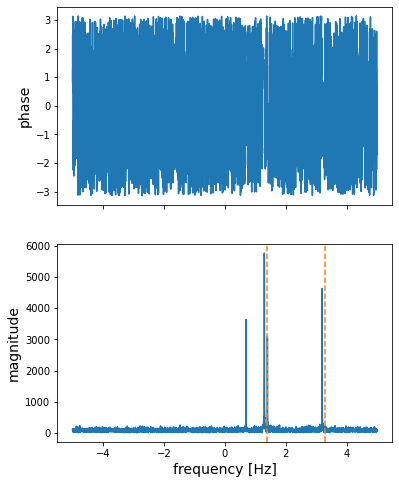

In [4]:
fft_freq = np.fft.fftshift(np.fft.fftfreq(4096, 1/sampling_rate))
fft_result_0 = np.fft.fftshift(np.fft.fft(sig_0[:4096]))
fft_result_1 = np.fft.fftshift(np.fft.fft(sig_1[:4096]))
fft_result_2 = np.fft.fftshift(np.fft.fft(sig_2[:4096]))

point_ind = np.searchsorted(fft_freq, 1.4, side='left')

%matplotlib inline
fig, ax = plt.subplots(2,1, sharex=True, figsize=(6,8))
ax[0].plot(fft_freq, np.angle(fft_result_0))
ax[1].plot(fft_freq, np.abs(fft_result_0))
draw_axvlines(axs=[ax[1]], xs=[f_init, f_last], ls='--', color='tab:orange')
ax[1].set_xlabel('frequency [Hz]', fontsize=14)
ax[0].set_ylabel('phase', fontsize=14)
ax[1].set_ylabel('magnitude', fontsize=14)
plt.show()

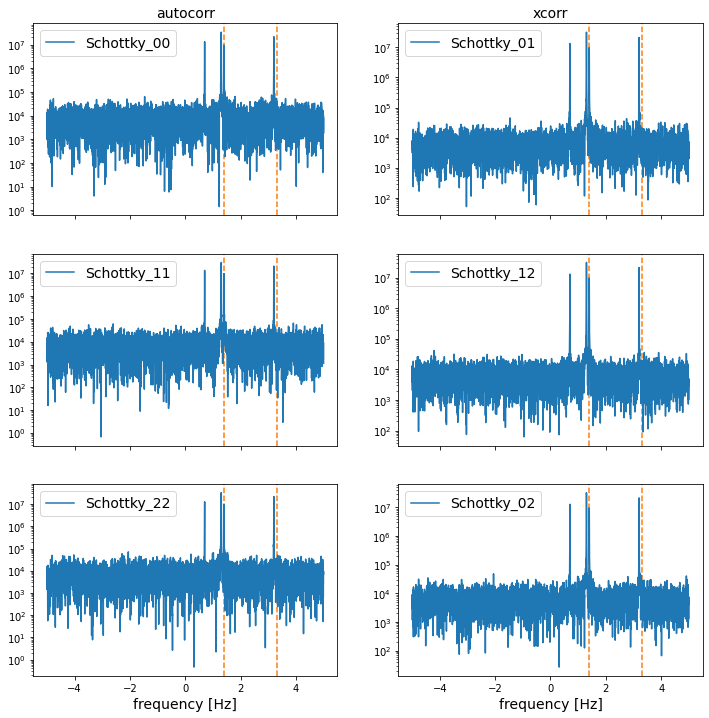

In [5]:
%matplotlib inline
fig, ax = plt.subplots(3,2, sharex=True, figsize=(12,12))
ax[0,0].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_0)), label='Schottky_00', zorder=1)
ax[0,1].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_1)), label='Schottky_01', zorder=1)
ax[1,0].semilogy(fft_freq, np.abs(fft_result_1*np.conjugate(fft_result_1)), label='Schottky_11', zorder=1)
ax[1,1].semilogy(fft_freq, np.abs(fft_result_1*np.conjugate(fft_result_2)), label='Schottky_12', zorder=1)
ax[2,0].semilogy(fft_freq, np.abs(fft_result_2*np.conjugate(fft_result_2)), label='Schottky_22', zorder=1)
ax[2,1].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_2)), label='Schottky_02', zorder=1)
draw_axvlines(axs=[ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0], ax[2,1]], xs=[f_init, f_last], ls='--', color='tab:orange', zorder=0)
ax[0,0].legend(fontsize=14)
ax[0,1].legend(fontsize=14)
ax[1,0].legend(fontsize=14)
ax[1,1].legend(fontsize=14)
ax[2,0].legend(fontsize=14)
ax[2,1].legend(fontsize=14)
ax[2,0].set_xlabel('frequency [Hz]', fontsize=14)
ax[2,1].set_xlabel('frequency [Hz]', fontsize=14)
ax[0,0].set_title('autocorr', fontsize=14)
ax[0,1].set_title('xcorr', fontsize=14)
plt.show()

In [6]:
from scipy.linalg import svd

result_s = []
fft_00, fft_01, fft_02 = fft_result_0*np.conjugate(fft_result_0), fft_result_0*np.conjugate(fft_result_1), fft_result_0*np.conjugate(fft_result_2)
fft_10, fft_11, fft_12 = fft_result_1*np.conjugate(fft_result_0), fft_result_1*np.conjugate(fft_result_1), fft_result_1*np.conjugate(fft_result_2)
fft_20, fft_21, fft_22 = fft_result_2*np.conjugate(fft_result_0), fft_result_2*np.conjugate(fft_result_1), fft_result_2*np.conjugate(fft_result_2)
for i in range(len(fft_result_0)):
    s = svd(np.array([[fft_00[i], fft_01[i], fft_02[i]], [fft_10[i], fft_11[i], fft_12[i]], [fft_20[i], fft_21[i], fft_22[i]]]), compute_uv=False)
    result_s.append(s)

result_s = np.array(result_s)
print(result_s)

[[1.76394154e+04 2.40445177e-13 1.83813817e-13]
 [3.19592930e+04 1.96435729e-12 8.55900221e-13]
 [2.38299693e+04 2.70138492e-12 6.82617954e-13]
 ...
 [1.81168493e+04 2.85617933e-12 1.46446512e-13]
 [1.36252855e+04 1.15878791e-12 3.05874658e-13]
 [1.60679133e+04 7.40249417e-13 2.04004666e-13]]


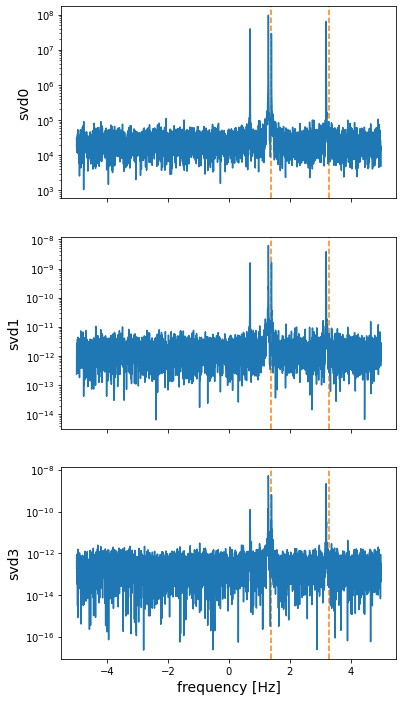

In [7]:
%matplotlib inline
fig, ax = plt.subplots(3,1, sharex=True, figsize=(6,12))
ax[0].semilogy(fft_freq, result_s[:,0], zorder=1)
ax[1].semilogy(fft_freq, result_s[:,1], zorder=1)
ax[2].semilogy(fft_freq, result_s[:,2], zorder=1)
draw_axvlines(axs=[ax[0], ax[1], ax[2]], xs=[f_init, f_last], ls='--', color='tab:orange', zorder=0)
ax[2].set_xlabel('frequency [Hz]', fontsize=14)
ax[0].set_ylabel('svd0', fontsize=14)
ax[1].set_ylabel('svd1', fontsize=14)
ax[2].set_ylabel('svd3', fontsize=14)
plt.yscale('log')
plt.show()

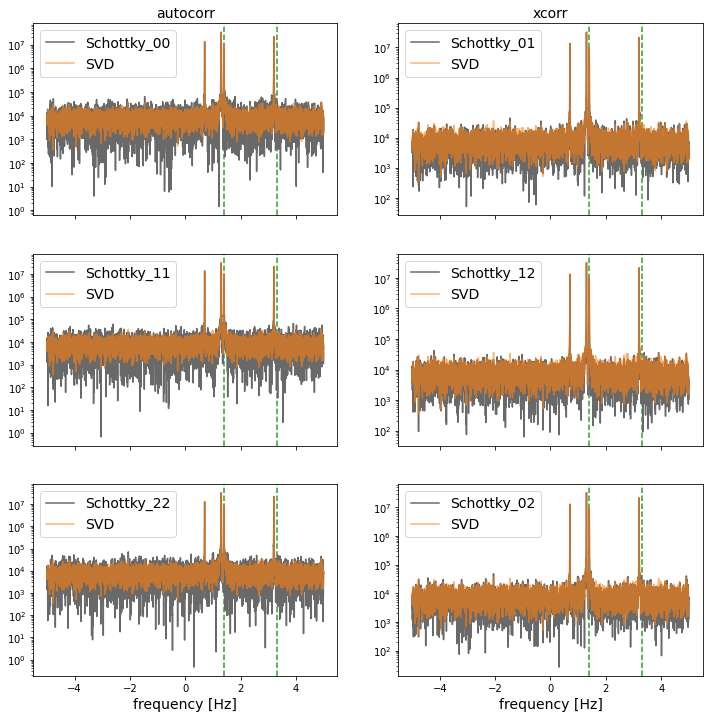

In [8]:
%matplotlib inline
fig, ax = plt.subplots(3,2, sharex=True, figsize=(12,12))
ax[0,0].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_0)), label='Schottky_00', zorder=1, color='dimgray')
ax[0,1].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_1)), label='Schottky_01', zorder=1, color='dimgray')
ax[1,0].semilogy(fft_freq, np.abs(fft_result_1*np.conjugate(fft_result_1)), label='Schottky_11', zorder=1, color='dimgray')
ax[1,1].semilogy(fft_freq, np.abs(fft_result_1*np.conjugate(fft_result_2)), label='Schottky_12', zorder=1, color='dimgray')
ax[2,0].semilogy(fft_freq, np.abs(fft_result_2*np.conjugate(fft_result_2)), label='Schottky_22', zorder=1, color='dimgray')
ax[2,1].semilogy(fft_freq, np.abs(fft_result_0*np.conjugate(fft_result_2)), label='Schottky_02', zorder=1, color='dimgray')
ax[0,0].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[0,1].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[1,0].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[1,1].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[2,0].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
ax[2,1].semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
draw_axvlines(axs=[ax[0,0], ax[0,1], ax[1,0], ax[1,1], ax[2,0], ax[2,1]], xs=[f_init, f_last], ls='--', color='tab:green', zorder=0)
ax[0,0].legend(fontsize=14)
ax[0,1].legend(fontsize=14)
ax[1,0].legend(fontsize=14)
ax[1,1].legend(fontsize=14)
ax[2,0].legend(fontsize=14)
ax[2,1].legend(fontsize=14)
ax[2,0].set_xlabel('frequency [Hz]', fontsize=14)
ax[2,1].set_xlabel('frequency [Hz]', fontsize=14)
ax[0,0].set_title('autocorr', fontsize=14)
ax[0,1].set_title('xcorr', fontsize=14)
plt.show()

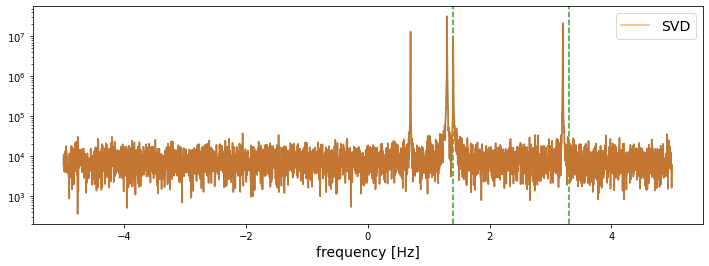

In [9]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(12,4))
ax.semilogy(fft_freq, (np.abs(fft_result_0*np.conjugate(fft_result_0))+np.abs(fft_result_1*np.conjugate(fft_result_1))+np.abs(fft_result_2*np.conjugate(fft_result_2)))/3, zorder=0, color='dimgray')
ax.semilogy(fft_freq, result_s[:,0]/3, zorder=1, alpha=0.6, color='tab:orange', label='SVD')
draw_axvlines(axs=[ax], xs=[f_init, f_last], ls='--', color='tab:green', zorder=0)
ax.legend(fontsize=14)
ax.set_xlabel('frequency [Hz]', fontsize=14)
plt.show()

In [22]:
fft_0_results, fft_1_results, fft_2_results = [], [], []
svd_results = []
for i in range(4096):
    fft_0_results.append(np.fft.fftshift(np.fft.fft(sig_0[i*10:(i*10+4096)])))
    fft_1_results.append(np.fft.fftshift(np.fft.fft(sig_1[i*10:(i*10+4096)])))
    fft_2_results.append(np.fft.fftshift(np.fft.fft(sig_2[i*10:(i*10+4096)])))
    fft_00_temp, fft_01_temp, fft_02_temp = fft_0_results[-1]*np.conjugate(fft_0_results[-1]), fft_0_results[-1]*np.conjugate(fft_1_results[-1]), fft_0_results[-1]*np.conjugate(fft_2_results[-1])
    fft_10_temp, fft_11_temp, fft_12_temp = fft_1_results[-1]*np.conjugate(fft_0_results[-1]), fft_1_results[-1]*np.conjugate(fft_1_results[-1]), fft_1_results[-1]*np.conjugate(fft_2_results[-1])
    fft_20_temp, fft_21_temp, fft_22_temp = fft_2_results[-1]*np.conjugate(fft_0_results[-1]), fft_2_results[-1]*np.conjugate(fft_1_results[-1]), fft_2_results[-1]*np.conjugate(fft_2_results[-1])
    svd_temp = []
    for j in range(len(fft_00_temp)):
        s = svd(np.array([[fft_00_temp[j], fft_01_temp[j], fft_02_temp[j]], [fft_10_temp[j], fft_11_temp[j], fft_12_temp[j]], [fft_20_temp[j], fft_21_temp[j], fft_22_temp[j]]]), compute_uv=False)
        svd_temp.append(s)
    svd_results.append(svd_temp)

point_ind_0 = np.searchsorted(fft_freq, f_init, side='left')
point_ind_1 = np.searchsorted(fft_freq, f_last, side='left')

fft_01_results = (np.array(fft_0_results) * np.conjugate(np.array(fft_1_results)))
fft_02_results = (np.array(fft_0_results) * np.conjugate(np.array(fft_2_results)))
fft_12_results = (np.array(fft_1_results) * np.conjugate(np.array(fft_2_results)))
fft_00_results = (np.abs(np.array(fft_0_results))**2).T
fft_11_results = (np.abs(np.array(fft_1_results))**2).T
fft_22_results = (np.abs(np.array(fft_2_results))**2).T
svd_results = np.array(svd_results)

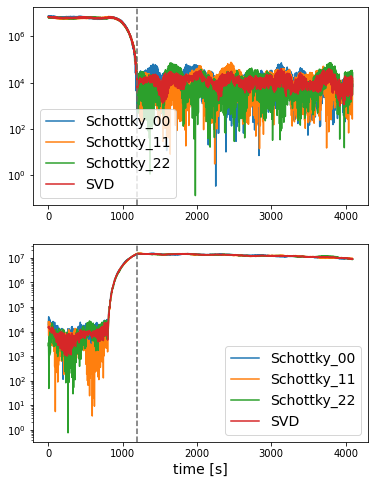

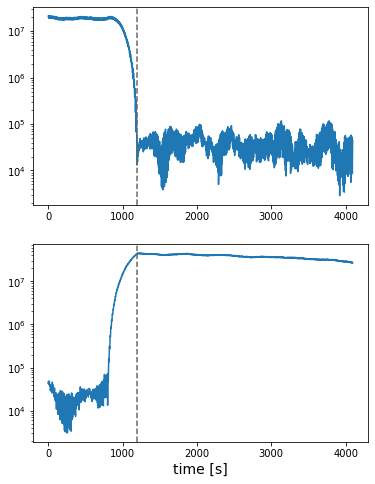

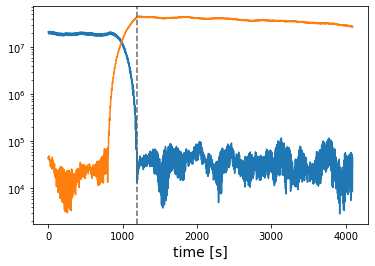

In [11]:
fig, ax = plt.subplots(2,1, figsize=(6,8))
ax[0].semilogy(t_range[:(4096*10):10], fft_00_results[point_ind_0,:], label='Schottky_00')
ax[0].semilogy(t_range[:(4096*10):10], fft_11_results[point_ind_0,:], label='Schottky_11')
ax[0].semilogy(t_range[:(4096*10):10], fft_22_results[point_ind_0,:], label='Schottky_22')
ax[0].semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_0,0]/3, label='SVD')
ax[0].axvline(x=time_change, color='dimgray', ls='--')
ax[1].semilogy(t_range[:(4096*10):10], fft_00_results[point_ind_1,:], label='Schottky_00')
ax[1].semilogy(t_range[:(4096*10):10], fft_11_results[point_ind_1,:], label='Schottky_11')
ax[1].semilogy(t_range[:(4096*10):10], fft_22_results[point_ind_1,:], label='Schottky_22')
ax[1].semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_1,0]/3, label='SVD')
ax[1].axvline(x=time_change, color='dimgray', ls='--')
ax[1].set_xlabel('time [s]', fontsize=14)
ax[0].legend(fontsize=14)
ax[1].legend(fontsize=14)
plt.show()

fig, ax = plt.subplots(2,1, figsize=(6,8))
ax[0].semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_0,0])
ax[0].axvline(x=time_change, color='dimgray', ls='--')
ax[1].semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_1,0])
ax[1].axvline(x=time_change, color='dimgray', ls='--')
ax[1].set_xlabel('time [s]', fontsize=14)
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_0,0])
ax.semilogy(t_range[:(4096*10):10], svd_results[:,point_ind_1,0])
ax.axvline(x=time_change, color='dimgray', ls='--')
ax.set_xlabel('time [s]', fontsize=14)
plt.show()

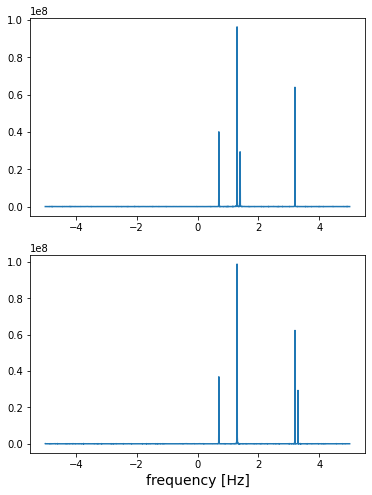

6628818.852079525


In [12]:
%matplotlib inline
fig, ax = plt.subplots(2,1, figsize=(6,8))
ax[0].plot(fft_freq, svd_results[1,:,0])
ax[1].plot(fft_freq, svd_results[4000,:,0])
ax[1].set_xlabel('frequency [Hz]', fontsize=14)
plt.show()
print(svd_results[4000,point_ind_1-1,0])

In [13]:
import matplotlib
cmap = matplotlib.colormaps['viridis']

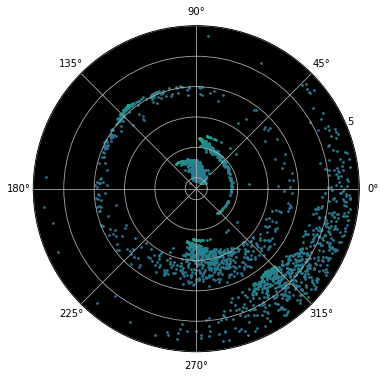

In [20]:
mag_results_total = np.abs(np.array(fft_0_results))
phase_results_total = np.angle(np.array(fft_0_results))

j0 = 600

%matplotlib inline
plt.figure(figsize=(6,6))
ax = plt.subplot(111, projection='polar')
ax.set_facecolor('black')
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
plt.show()

mag_results_total = np.abs(np.array(fft_1_results))
phase_results_total = np.angle(np.array(fft_1_results))

j0 = 600

%matplotlib inline
plt.figure(figsize=(6,6))
ax = plt.subplot(111, projection='polar')
ax.set_facecolor('black')
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
plt.show()

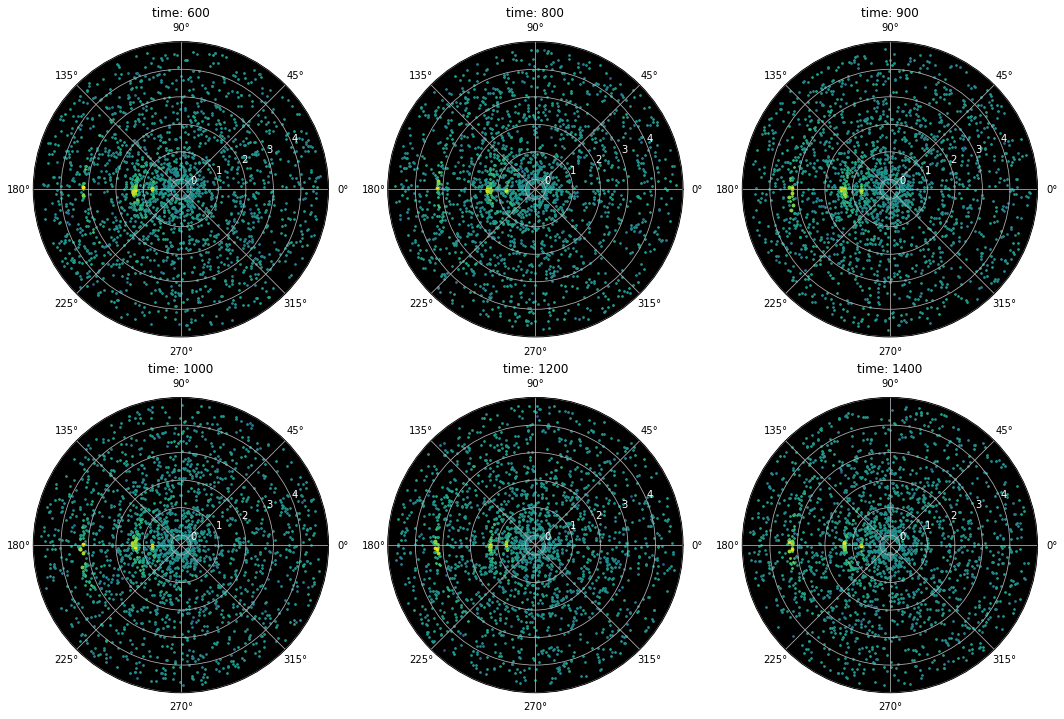

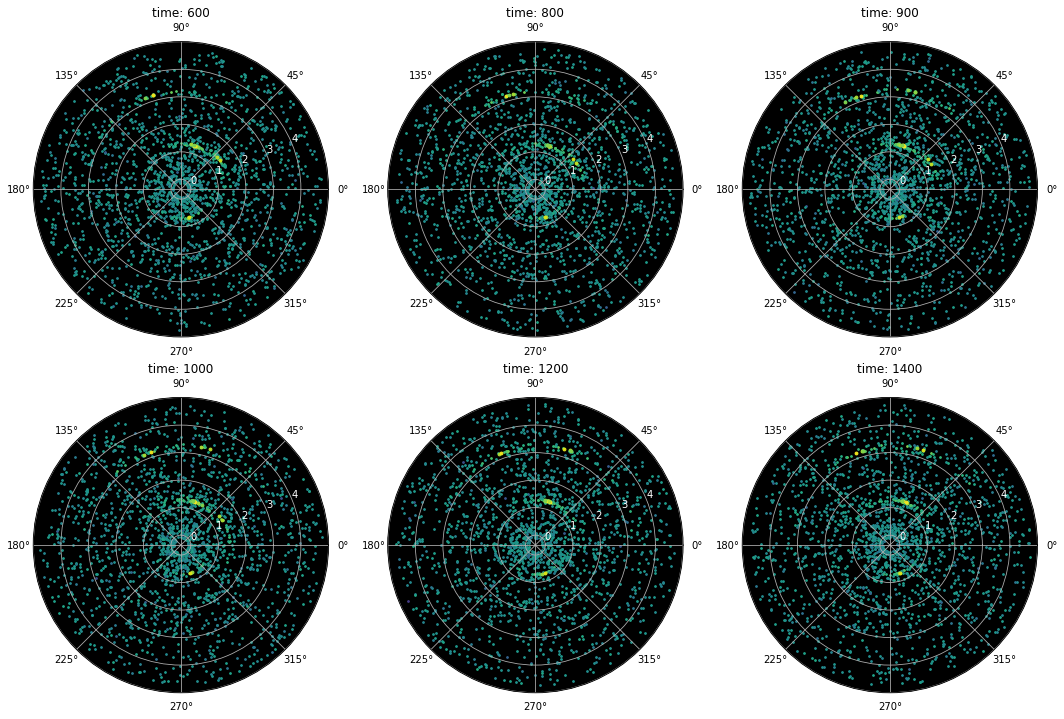

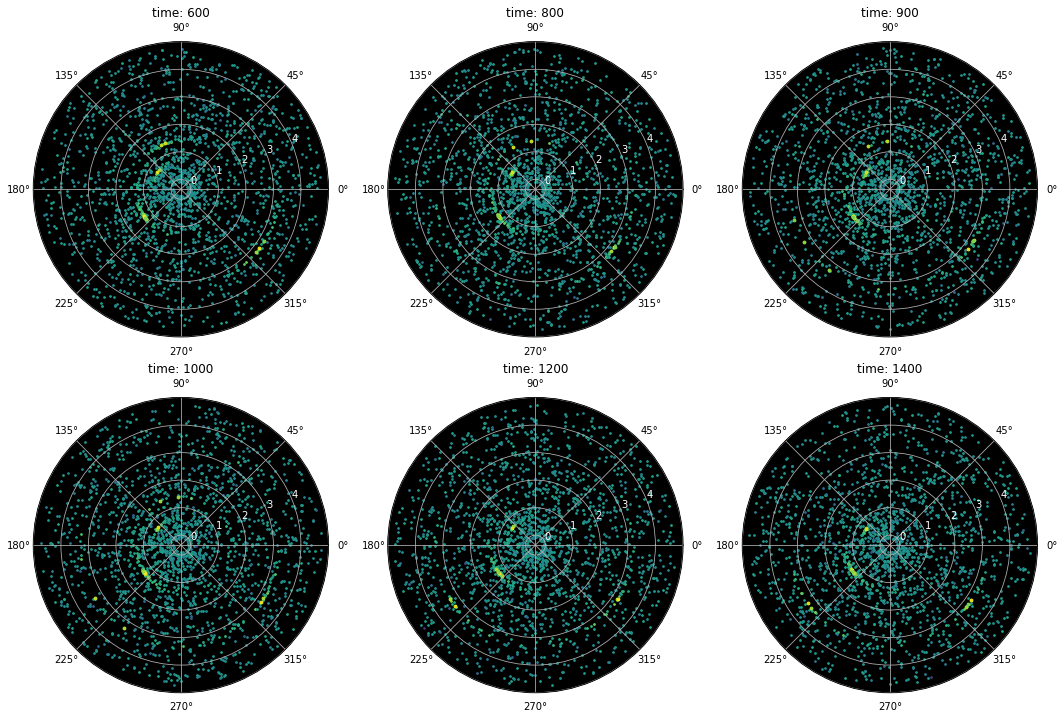

In [14]:
j0 = 600
point_shift_0 = 200
point_shift_1 = 300
point_shift_2 = 400
point_shift_3 = 600
point_shift_4 = 800

mag_results_total = np.abs(fft_01_results)
phase_results_total = np.angle(fft_01_results)

norm = matplotlib.colors.LogNorm(vmin=np.min(mag_results_total), vmax=np.max(mag_results_total))
#norm = matplotlib.colors.Normalize(vmin=np.min(mag_results_total[j]), vmax=np.max(mag_results_total[j]))

%matplotlib inline
plt.figure(figsize=(18,12))
ax0 = plt.subplot(231, projection='polar')
ax0.set_title('time: {:}'.format(j0))
ax0.set_facecolor('black')
rlabels = ax0.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
ax1 = plt.subplot(232, projection='polar')
ax1.set_title('time: {:}'.format(j0+point_shift_0))
ax1.set_facecolor('black')
rlabels = ax1.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_0][i]) > 0.8:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=8, zorder=1)
    else:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=3, zorder=0)
ax2 = plt.subplot(233, projection='polar')
ax2.set_title('time: {:}'.format(j0+point_shift_1))
ax2.set_facecolor('black')
rlabels = ax2.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_1][i]) > 0.8:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=8, zorder=1)
    else:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=3, zorder=0)
ax3 = plt.subplot(234, projection='polar')
ax3.set_title('time: {:}'.format(j0+point_shift_2))
ax3.set_facecolor('black')
rlabels = ax3.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_2][i]) > 0.8:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=8, zorder=1)
    else:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=3, zorder=0)
ax4 = plt.subplot(235, projection='polar')
ax4.set_title('time: {:}'.format(j0+point_shift_3))
ax4.set_facecolor('black')
rlabels = ax4.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_3][i]) > 0.8:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=8, zorder=1)
    else:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=3, zorder=0)
ax5 = plt.subplot(236, projection='polar')
ax5.set_title('time: {:}'.format(j0+point_shift_4))
ax5.set_facecolor('black')
rlabels = ax5.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_4][i]) > 0.8:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=8, zorder=1)
    else:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=3, zorder=0)
plt.show()

mag_results_total = np.abs(fft_0_results[:-11]*np.conjugate(fft_1_results[11:]))
phase_results_total = np.angle(fft_0_results[:-11]*np.conjugate(fft_1_results[11:]))

%matplotlib inline
plt.figure(figsize=(18,12))
ax0 = plt.subplot(231, projection='polar')
ax0.set_title('time: {:}'.format(j0))
ax0.set_facecolor('black')
rlabels = ax0.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
ax1 = plt.subplot(232, projection='polar')
ax1.set_title('time: {:}'.format(j0+point_shift_0))
ax1.set_facecolor('black')
rlabels = ax1.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_0][i]) > 0.8:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=8, zorder=1)
    else:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=3, zorder=0)
ax2 = plt.subplot(233, projection='polar')
ax2.set_title('time: {:}'.format(j0+point_shift_1))
ax2.set_facecolor('black')
rlabels = ax2.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_1][i]) > 0.8:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=8, zorder=1)
    else:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=3, zorder=0)
ax3 = plt.subplot(234, projection='polar')
ax3.set_title('time: {:}'.format(j0+point_shift_2))
ax3.set_facecolor('black')
rlabels = ax3.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_2][i]) > 0.8:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=8, zorder=1)
    else:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=3, zorder=0)
ax4 = plt.subplot(235, projection='polar')
ax4.set_title('time: {:}'.format(j0+point_shift_3))
ax4.set_facecolor('black')
rlabels = ax4.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_3][i]) > 0.8:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=8, zorder=1)
    else:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=3, zorder=0)
ax5 = plt.subplot(236, projection='polar')
ax5.set_title('time: {:}'.format(j0+point_shift_4))
ax5.set_facecolor('black')
rlabels = ax5.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_4][i]) > 0.8:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=8, zorder=1)
    else:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=3, zorder=0)
plt.show()

mag_results_total = np.abs(fft_0_results[:-53]*np.conjugate(fft_1_results[53:]))
phase_results_total = np.angle(fft_0_results[:-53]*np.conjugate(fft_1_results[53:]))

%matplotlib inline
plt.figure(figsize=(18,12))
ax0 = plt.subplot(231, projection='polar')
ax0.set_title('time: {:}'.format(j0))
ax0.set_facecolor('black')
rlabels = ax0.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
ax1 = plt.subplot(232, projection='polar')
ax1.set_title('time: {:}'.format(j0+point_shift_0))
ax1.set_facecolor('black')
rlabels = ax1.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_0][i]) > 0.8:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=8, zorder=1)
    else:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=3, zorder=0)
ax2 = plt.subplot(233, projection='polar')
ax2.set_title('time: {:}'.format(j0+point_shift_1))
ax2.set_facecolor('black')
rlabels = ax2.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_1][i]) > 0.8:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=8, zorder=1)
    else:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=3, zorder=0)
ax3 = plt.subplot(234, projection='polar')
ax3.set_title('time: {:}'.format(j0+point_shift_2))
ax3.set_facecolor('black')
rlabels = ax3.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_2][i]) > 0.8:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=8, zorder=1)
    else:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=3, zorder=0)
ax4 = plt.subplot(235, projection='polar')
ax4.set_title('time: {:}'.format(j0+point_shift_3))
ax4.set_facecolor('black')
rlabels = ax4.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_3][i]) > 0.8:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=8, zorder=1)
    else:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=3, zorder=0)
ax5 = plt.subplot(236, projection='polar')
ax5.set_title('time: {:}'.format(j0+point_shift_4))
ax5.set_facecolor('black')
rlabels = ax5.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_4][i]) > 0.8:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=8, zorder=1)
    else:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=3, zorder=0)
plt.show()

In [15]:
t_range, sig_0, sig_1, sig_2 = schottky_decay_signal(amp_init=amp_init, amp_last=amp_last, f_init=f_init, f_last=f_last, time_change=time_change, delta_f_ratio=delta_f_ratio, sampling_rate=sampling_rate, phase_noise_detectorDiff=False, phase_noise_on=True, amplitude_noise_on=True, noise_scale=.1)

fft_0_results, fft_1_results, fft_2_results = [], [], []
for i in range(4096):
    fft_0_results.append(np.fft.fftshift(np.fft.fft(sig_0[i*10:(i*10+4096)])))
    fft_1_results.append(np.fft.fftshift(np.fft.fft(sig_1[i*10:(i*10+4096)])))
    fft_2_results.append(np.fft.fftshift(np.fft.fft(sig_2[i*10:(i*10+4096)])))


fft_01_results = (np.array(fft_0_results) * np.conjugate(np.array(fft_1_results)))
fft_02_results = (np.array(fft_0_results) * np.conjugate(np.array(fft_2_results)))
fft_12_results = (np.array(fft_1_results) * np.conjugate(np.array(fft_2_results)))
fft_00_results = (np.abs(np.array(fft_0_results))**2).T
fft_11_results = (np.abs(np.array(fft_1_results))**2).T
fft_22_results = (np.abs(np.array(fft_2_results))**2).T

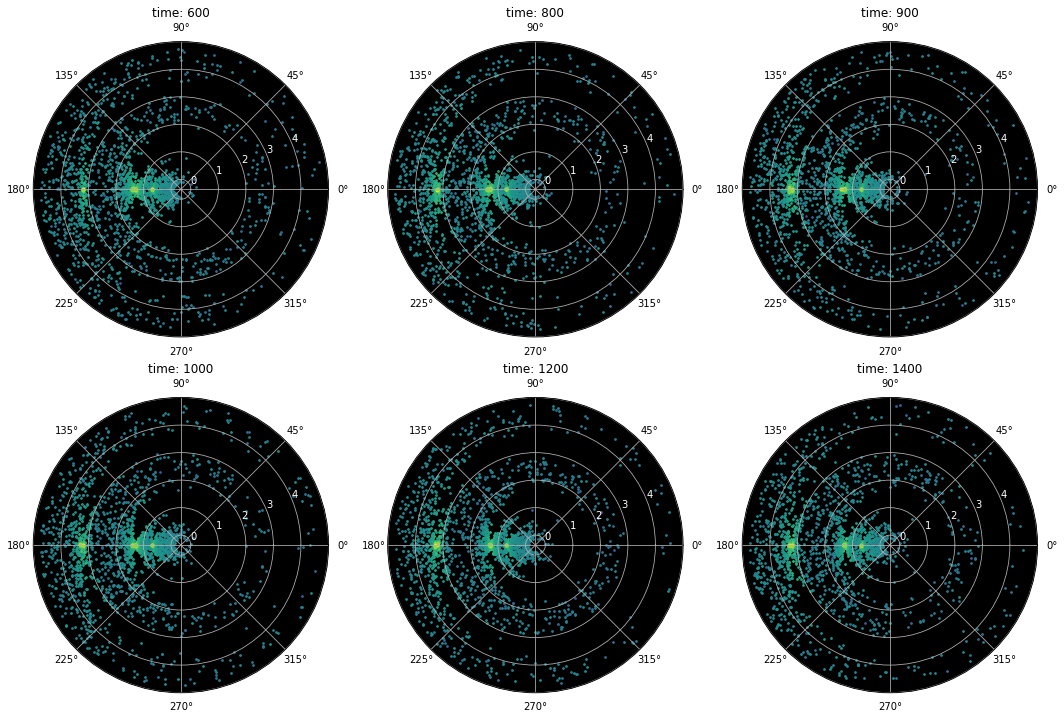

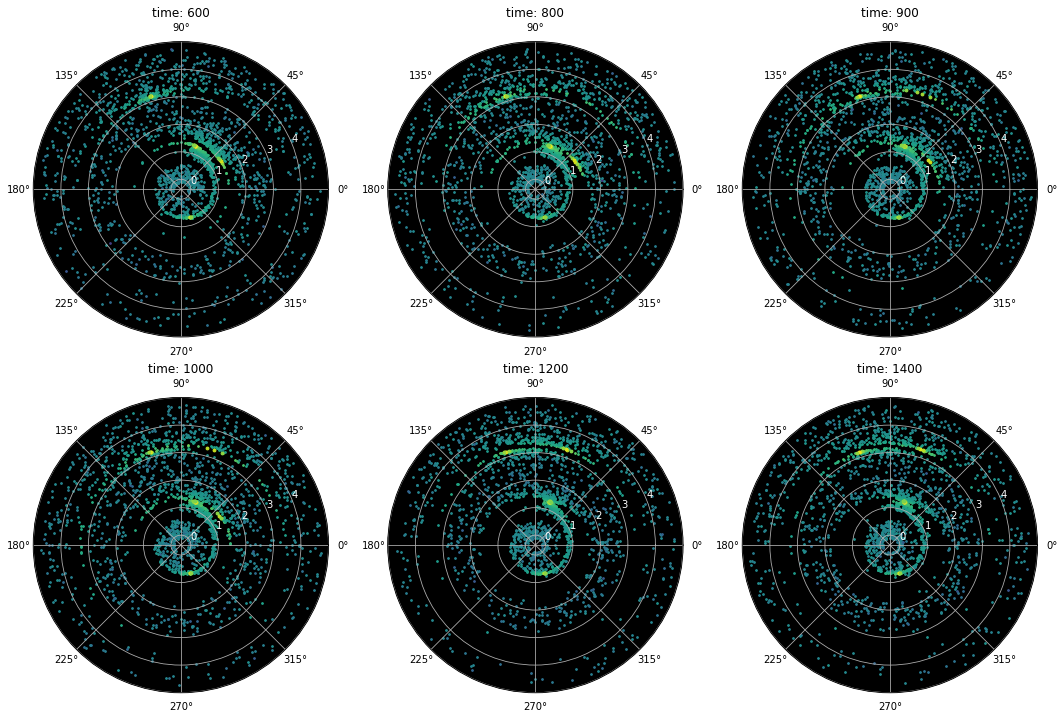

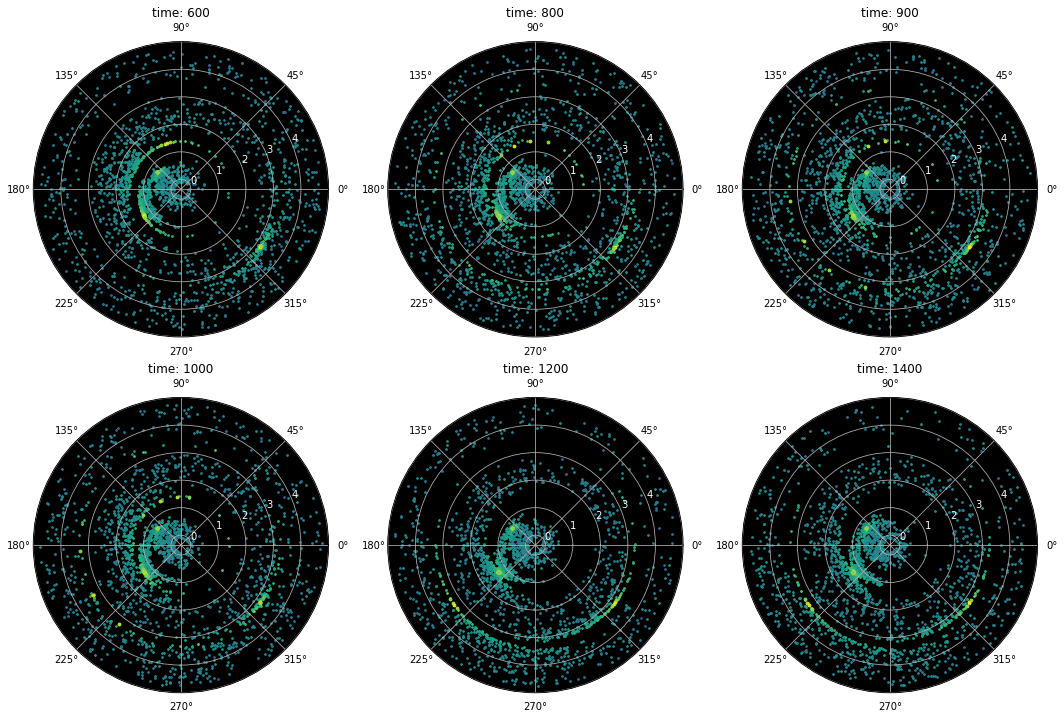

In [16]:
j0 = 600
point_shift_0 = 200
point_shift_1 = 300
point_shift_2 = 400
point_shift_3 = 600
point_shift_4 = 800

mag_results_total = np.abs(fft_01_results)
phase_results_total = np.angle(fft_01_results)

norm = matplotlib.colors.LogNorm(vmin=np.min(mag_results_total), vmax=np.max(mag_results_total))
#norm = matplotlib.colors.Normalize(vmin=np.min(mag_results_total[j]), vmax=np.max(mag_results_total[j]))

%matplotlib inline
plt.figure(figsize=(18,12))
ax0 = plt.subplot(231, projection='polar')
ax0.set_title('time: {:}'.format(j0))
ax0.set_facecolor('black')
rlabels = ax0.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
ax1 = plt.subplot(232, projection='polar')
ax1.set_title('time: {:}'.format(j0+point_shift_0))
ax1.set_facecolor('black')
rlabels = ax1.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_0][i]) > 0.8:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=8, zorder=1)
    else:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=3, zorder=0)
ax2 = plt.subplot(233, projection='polar')
ax2.set_title('time: {:}'.format(j0+point_shift_1))
ax2.set_facecolor('black')
rlabels = ax2.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_1][i]) > 0.8:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=8, zorder=1)
    else:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=3, zorder=0)
ax3 = plt.subplot(234, projection='polar')
ax3.set_title('time: {:}'.format(j0+point_shift_2))
ax3.set_facecolor('black')
rlabels = ax3.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_2][i]) > 0.8:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=8, zorder=1)
    else:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=3, zorder=0)
ax4 = plt.subplot(235, projection='polar')
ax4.set_title('time: {:}'.format(j0+point_shift_3))
ax4.set_facecolor('black')
rlabels = ax4.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_3][i]) > 0.8:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=8, zorder=1)
    else:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=3, zorder=0)
ax5 = plt.subplot(236, projection='polar')
ax5.set_title('time: {:}'.format(j0+point_shift_4))
ax5.set_facecolor('black')
rlabels = ax5.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_4][i]) > 0.8:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=8, zorder=1)
    else:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=3, zorder=0)
plt.show()

mag_results_total = np.abs(fft_0_results[:-11]*np.conjugate(fft_1_results[11:]))
phase_results_total = np.angle(fft_0_results[:-11]*np.conjugate(fft_1_results[11:]))

%matplotlib inline
plt.figure(figsize=(18,12))
ax0 = plt.subplot(231, projection='polar')
ax0.set_title('time: {:}'.format(j0))
ax0.set_facecolor('black')
rlabels = ax0.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
ax1 = plt.subplot(232, projection='polar')
ax1.set_title('time: {:}'.format(j0+point_shift_0))
ax1.set_facecolor('black')
rlabels = ax1.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_0][i]) > 0.8:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=8, zorder=1)
    else:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=3, zorder=0)
ax2 = plt.subplot(233, projection='polar')
ax2.set_title('time: {:}'.format(j0+point_shift_1))
ax2.set_facecolor('black')
rlabels = ax2.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_1][i]) > 0.8:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=8, zorder=1)
    else:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=3, zorder=0)
ax3 = plt.subplot(234, projection='polar')
ax3.set_title('time: {:}'.format(j0+point_shift_2))
ax3.set_facecolor('black')
rlabels = ax3.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_2][i]) > 0.8:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=8, zorder=1)
    else:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=3, zorder=0)
ax4 = plt.subplot(235, projection='polar')
ax4.set_title('time: {:}'.format(j0+point_shift_3))
ax4.set_facecolor('black')
rlabels = ax4.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_3][i]) > 0.8:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=8, zorder=1)
    else:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=3, zorder=0)
ax5 = plt.subplot(236, projection='polar')
ax5.set_title('time: {:}'.format(j0+point_shift_4))
ax5.set_facecolor('black')
rlabels = ax5.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_4][i]) > 0.8:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=8, zorder=1)
    else:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=3, zorder=0)
plt.show()

mag_results_total = np.abs(fft_0_results[:-53]*np.conjugate(fft_1_results[53:]))
phase_results_total = np.angle(fft_0_results[:-53]*np.conjugate(fft_1_results[53:]))

%matplotlib inline
plt.figure(figsize=(18,12))
ax0 = plt.subplot(231, projection='polar')
ax0.set_title('time: {:}'.format(j0))
ax0.set_facecolor('black')
rlabels = ax0.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
ax1 = plt.subplot(232, projection='polar')
ax1.set_title('time: {:}'.format(j0+point_shift_0))
ax1.set_facecolor('black')
rlabels = ax1.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_0][i]) > 0.8:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=8, zorder=1)
    else:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=3, zorder=0)
ax2 = plt.subplot(233, projection='polar')
ax2.set_title('time: {:}'.format(j0+point_shift_1))
ax2.set_facecolor('black')
rlabels = ax2.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_1][i]) > 0.8:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=8, zorder=1)
    else:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=3, zorder=0)
ax3 = plt.subplot(234, projection='polar')
ax3.set_title('time: {:}'.format(j0+point_shift_2))
ax3.set_facecolor('black')
rlabels = ax3.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_2][i]) > 0.8:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=8, zorder=1)
    else:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=3, zorder=0)
ax4 = plt.subplot(235, projection='polar')
ax4.set_title('time: {:}'.format(j0+point_shift_3))
ax4.set_facecolor('black')
rlabels = ax4.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_3][i]) > 0.8:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=8, zorder=1)
    else:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=3, zorder=0)
ax5 = plt.subplot(236, projection='polar')
ax5.set_title('time: {:}'.format(j0+point_shift_4))
ax5.set_facecolor('black')
rlabels = ax5.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_4][i]) > 0.8:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=8, zorder=1)
    else:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=3, zorder=0)
plt.show()

In [17]:
t_range, sig_0, sig_1, sig_2 = schottky_decay_signal(amp_init=amp_init, amp_last=amp_last, f_init=f_init, f_last=f_last, time_change=time_change, delta_f_ratio=delta_f_ratio, sampling_rate=sampling_rate, phase_noise_detectorDiff=False, phase_noise_on=True, amplitude_noise_on=True, noise_scale=.01)

fft_0_results, fft_1_results, fft_2_results = [], [], []
for i in range(4096):
    fft_0_results.append(np.fft.fftshift(np.fft.fft(sig_0[i*10:(i*10+4096)])))
    fft_1_results.append(np.fft.fftshift(np.fft.fft(sig_1[i*10:(i*10+4096)])))
    fft_2_results.append(np.fft.fftshift(np.fft.fft(sig_2[i*10:(i*10+4096)])))


fft_01_results = (np.array(fft_0_results) * np.conjugate(np.array(fft_1_results)))
fft_02_results = (np.array(fft_0_results) * np.conjugate(np.array(fft_2_results)))
fft_12_results = (np.array(fft_1_results) * np.conjugate(np.array(fft_2_results)))
fft_00_results = (np.abs(np.array(fft_0_results))**2).T
fft_11_results = (np.abs(np.array(fft_1_results))**2).T
fft_22_results = (np.abs(np.array(fft_2_results))**2).T

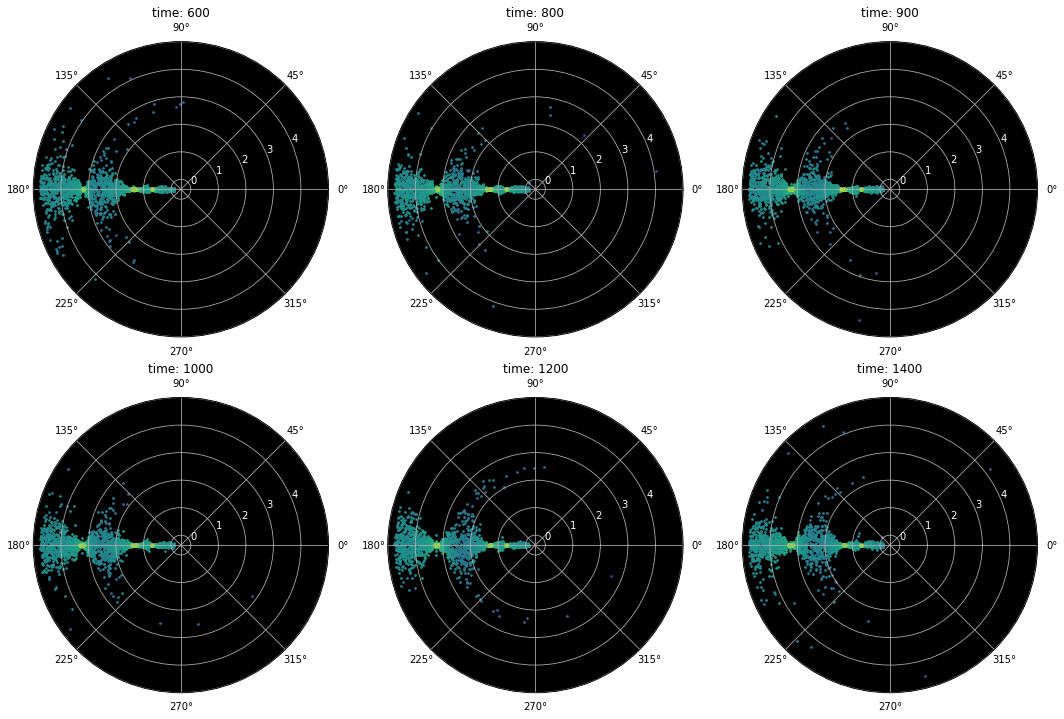

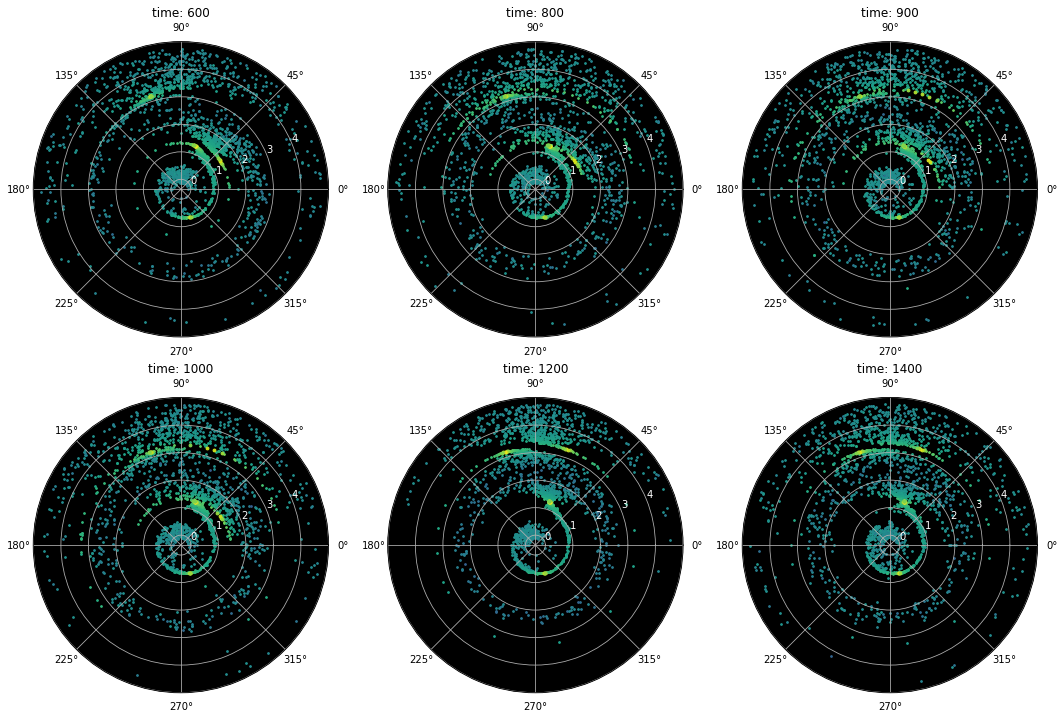

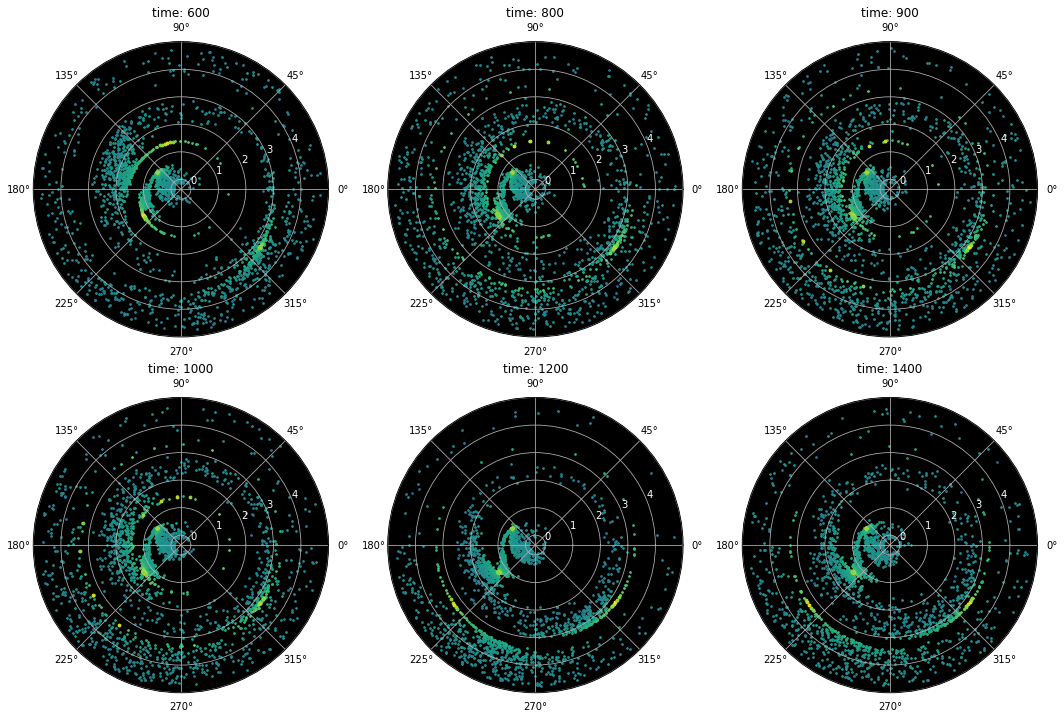

In [18]:
j0 = 600
point_shift_0 = 200
point_shift_1 = 300
point_shift_2 = 400
point_shift_3 = 600
point_shift_4 = 800

mag_results_total = np.abs(fft_01_results)
phase_results_total = np.angle(fft_01_results)

norm = matplotlib.colors.LogNorm(vmin=np.min(mag_results_total), vmax=np.max(mag_results_total))
#norm = matplotlib.colors.Normalize(vmin=np.min(mag_results_total[j]), vmax=np.max(mag_results_total[j]))

%matplotlib inline
plt.figure(figsize=(18,12))
ax0 = plt.subplot(231, projection='polar')
ax0.set_title('time: {:}'.format(j0))
ax0.set_facecolor('black')
rlabels = ax0.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
ax1 = plt.subplot(232, projection='polar')
ax1.set_title('time: {:}'.format(j0+point_shift_0))
ax1.set_facecolor('black')
rlabels = ax1.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_0][i]) > 0.8:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=8, zorder=1)
    else:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=3, zorder=0)
ax2 = plt.subplot(233, projection='polar')
ax2.set_title('time: {:}'.format(j0+point_shift_1))
ax2.set_facecolor('black')
rlabels = ax2.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_1][i]) > 0.8:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=8, zorder=1)
    else:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=3, zorder=0)
ax3 = plt.subplot(234, projection='polar')
ax3.set_title('time: {:}'.format(j0+point_shift_2))
ax3.set_facecolor('black')
rlabels = ax3.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_2][i]) > 0.8:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=8, zorder=1)
    else:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=3, zorder=0)
ax4 = plt.subplot(235, projection='polar')
ax4.set_title('time: {:}'.format(j0+point_shift_3))
ax4.set_facecolor('black')
rlabels = ax4.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_3][i]) > 0.8:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=8, zorder=1)
    else:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=3, zorder=0)
ax5 = plt.subplot(236, projection='polar')
ax5.set_title('time: {:}'.format(j0+point_shift_4))
ax5.set_facecolor('black')
rlabels = ax5.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_4][i]) > 0.8:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=8, zorder=1)
    else:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=3, zorder=0)
plt.show()

mag_results_total = np.abs(fft_0_results[:-11]*np.conjugate(fft_1_results[11:]))
phase_results_total = np.angle(fft_0_results[:-11]*np.conjugate(fft_1_results[11:]))

%matplotlib inline
plt.figure(figsize=(18,12))
ax0 = plt.subplot(231, projection='polar')
ax0.set_title('time: {:}'.format(j0))
ax0.set_facecolor('black')
rlabels = ax0.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
ax1 = plt.subplot(232, projection='polar')
ax1.set_title('time: {:}'.format(j0+point_shift_0))
ax1.set_facecolor('black')
rlabels = ax1.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_0][i]) > 0.8:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=8, zorder=1)
    else:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=3, zorder=0)
ax2 = plt.subplot(233, projection='polar')
ax2.set_title('time: {:}'.format(j0+point_shift_1))
ax2.set_facecolor('black')
rlabels = ax2.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_1][i]) > 0.8:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=8, zorder=1)
    else:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=3, zorder=0)
ax3 = plt.subplot(234, projection='polar')
ax3.set_title('time: {:}'.format(j0+point_shift_2))
ax3.set_facecolor('black')
rlabels = ax3.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_2][i]) > 0.8:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=8, zorder=1)
    else:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=3, zorder=0)
ax4 = plt.subplot(235, projection='polar')
ax4.set_title('time: {:}'.format(j0+point_shift_3))
ax4.set_facecolor('black')
rlabels = ax4.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_3][i]) > 0.8:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=8, zorder=1)
    else:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=3, zorder=0)
ax5 = plt.subplot(236, projection='polar')
ax5.set_title('time: {:}'.format(j0+point_shift_4))
ax5.set_facecolor('black')
rlabels = ax5.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_4][i]) > 0.8:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=8, zorder=1)
    else:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=3, zorder=0)
plt.show()

mag_results_total = np.abs(fft_0_results[:-53]*np.conjugate(fft_1_results[53:]))
phase_results_total = np.angle(fft_0_results[:-53]*np.conjugate(fft_1_results[53:]))

%matplotlib inline
plt.figure(figsize=(18,12))
ax0 = plt.subplot(231, projection='polar')
ax0.set_title('time: {:}'.format(j0))
ax0.set_facecolor('black')
rlabels = ax0.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0][i]) > 0.8:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=8, zorder=1)
    else:
        ax0.scatter(phase_results_total[j0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0][i])), s=3, zorder=0)
ax1 = plt.subplot(232, projection='polar')
ax1.set_title('time: {:}'.format(j0+point_shift_0))
ax1.set_facecolor('black')
rlabels = ax1.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_0][i]) > 0.8:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=8, zorder=1)
    else:
        ax1.scatter(phase_results_total[j0+point_shift_0][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_0][i])), s=3, zorder=0)
ax2 = plt.subplot(233, projection='polar')
ax2.set_title('time: {:}'.format(j0+point_shift_1))
ax2.set_facecolor('black')
rlabels = ax2.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_1][i]) > 0.8:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=8, zorder=1)
    else:
        ax2.scatter(phase_results_total[j0+point_shift_1][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_1][i])), s=3, zorder=0)
ax3 = plt.subplot(234, projection='polar')
ax3.set_title('time: {:}'.format(j0+point_shift_2))
ax3.set_facecolor('black')
rlabels = ax3.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_2][i]) > 0.8:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=8, zorder=1)
    else:
        ax3.scatter(phase_results_total[j0+point_shift_2][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_2][i])), s=3, zorder=0)
ax4 = plt.subplot(235, projection='polar')
ax4.set_title('time: {:}'.format(j0+point_shift_3))
ax4.set_facecolor('black')
rlabels = ax4.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_3][i]) > 0.8:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=8, zorder=1)
    else:
        ax4.scatter(phase_results_total[j0+point_shift_3][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_3][i])), s=3, zorder=0)
ax5 = plt.subplot(236, projection='polar')
ax5.set_title('time: {:}'.format(j0+point_shift_4))
ax5.set_facecolor('black')
rlabels = ax5.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
for i in range(2000, 4000):
    if norm(mag_results_total[j0+point_shift_4][i]) > 0.8:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=8, zorder=1)
    else:
        ax5.scatter(phase_results_total[j0+point_shift_4][i], fft_freq[i], color=cmap(norm(mag_results_total[j0+point_shift_4][i])), s=3, zorder=0)
plt.show()